In [1]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np

train_embeddings = np.load("/content/drive/MyDrive/fraud_detection_pipeline/data/embeddings/train_cls_embeddings.npy")
test_embeddings = np.load("/content/drive/MyDrive/fraud_detection_pipeline/data/embeddings/test_cls_embeddings.npy")


In [1]:
# from sklearn.metrics.pairwise import cosine_similarity
# import networkx as nx
# import numpy as np

# # Combine train + test embeddings for a full graph
# all_embeddings = np.vstack((train_embeddings, test_embeddings))
# num_nodes = len(all_embeddings)

# # Compute cosine similarity matrix
# similarity_matrix = cosine_similarity(all_embeddings)

# # Threshold to form edges (tune this)
# threshold = 0.9

# # Build the graph
# G = nx.Graph()
# G.add_nodes_from(range(num_nodes))  # user nodes

# # Add edges based on similarity
# for i in range(num_nodes):
#     for j in range(i + 1, num_nodes):
#         if similarity_matrix[i][j] > threshold:
#             G.add_edge(i, j, weight=similarity_matrix[i][j])


Use a sparse k-NN or top-k similarity approach instead of full cosine matrix-->less compute required

In [10]:
import pandas as pd

X_train = pd.read_csv('/content/drive/MyDrive/fraud_detection_pipeline/data/training_&_testing/X_train.csv')
y_train = pd.read_csv('/content/drive/MyDrive/fraud_detection_pipeline/data/training_&_testing/y_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/fraud_detection_pipeline/data/training_&_testing/X_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/fraud_detection_pipeline/data/training_&_testing/y_test.csv')

In [12]:
from sklearn.neighbors import NearestNeighbors
import networkx as nx
import numpy as np

# Combine embeddings
all_embeddings = np.vstack((train_embeddings, test_embeddings))
num_nodes = len(all_embeddings)

# Use k-Nearest Neighbors to avoid full matrix computation
k = 10  # number of neighbors (tune this)
nn_model = NearestNeighbors(n_neighbors=k + 1, metric='cosine')  # +1 to exclude self
nn_model.fit(all_embeddings)

# Get k nearest neighbors (and distances)
distances, indices = nn_model.kneighbors(all_embeddings)

# Build graph
G = nx.Graph()
G.add_nodes_from(range(num_nodes))

for i in range(num_nodes):
    for j in range(1, k + 1):  # skip self-match at index 0
        neighbor = indices[i][j]
        similarity = 1 - distances[i][j]  # convert cosine distance back to similarity
        if similarity > 0.9:  # optional thresholding
            G.add_edge(i, neighbor, weight=similarity)


In [14]:
# import matplotlib.pyplot as plt
# import networkx as nx

# # Ensure these are defined:
# # - G: the graph you've built
# # - labels: a list or array with the fraud labels (0 or 1), one per node
# # - pos: a layout dictionary with node positions

# # If not already defined, generate node positions:
# pos = nx.spring_layout(G, seed=42)  # deterministic layout

# # Color nodes: red = fraud (1), green = benign (0)
# colors = ['red' if label == 1 else 'green' for label in labels]

# # Plotting
# plt.figure(figsize=(10, 10))
# nx.draw(
#     G,
#     pos,
#     node_size=30,
#     node_color=colors,
#     edge_color='lightgray',
#     with_labels=False
# )
# plt.title("Fraud (Red) vs Benign (Green) Users in Graph")
# plt.show()


In [7]:
# Run in a Colab cell:
!pip install torch-geometric torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-$(python3 -c "import torch; print(torch.__version__)").html


Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


Prepare Data for PyG

In [13]:
from torch_geometric.data import Data
import torch

# Convert networkx graph to edge index
edge_index = torch.tensor(list(G.edges)).t().contiguous()

# Node features = your [CLS] embeddings
x = torch.tensor(all_embeddings, dtype=torch.float)

# Labels (optional, if supervised)
labels = torch.tensor(np.concatenate([y_train.values, y_test.values]), dtype=torch.long)

# Create PyG data object
data = Data(x=x, edge_index=edge_index, y=labels)


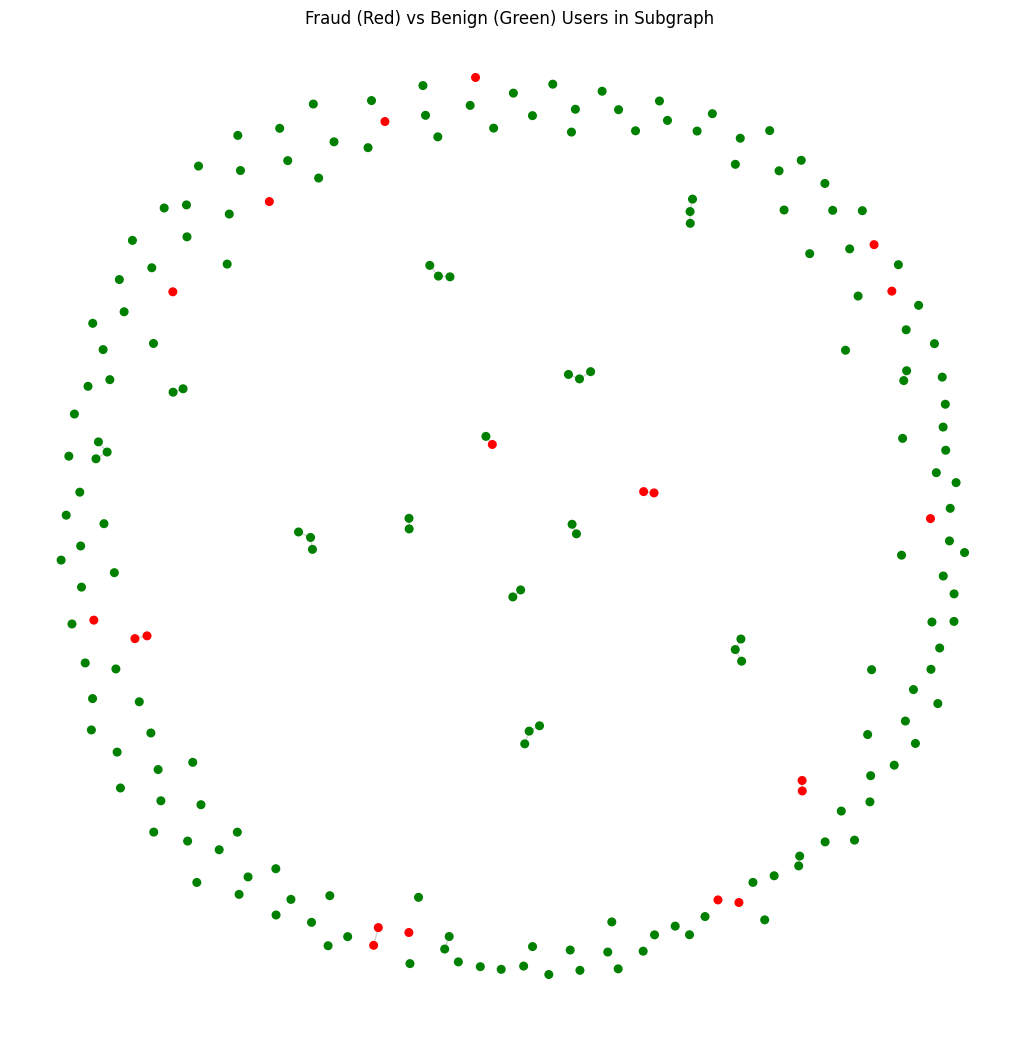

In [16]:
sub_nodes = list(G.nodes)[:200]
G_sub = G.subgraph(sub_nodes)
pos = nx.spring_layout(G_sub, seed=42)

sub_labels = [labels[n] for n in sub_nodes]
colors = ['red' if label == 1 else 'green' for label in sub_labels]

plt.figure(figsize=(10, 10))
nx.draw(G_sub, pos, node_size=30, node_color=colors, edge_color='lightgray', with_labels=False)
plt.title("Fraud (Red) vs Benign (Green) Users in Subgraph")
plt.show()


In [20]:
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F
from torch.nn import Module

class GraphSAGE(Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


In [23]:

# # this is requiring a lot of compute so we cannot get it
# import matplotlib.pyplot as plt
# import networkx as nx

# # Ensure these are defined:
# # - G: the graph you've built
# # - labels: a list or array with the fraud labels (0 or 1), one per node
# # - pos: a layout dictionary with node positions

# # If not already defined, generate node positions:
# pos = nx.spring_layout(G, seed=42)  # deterministic layout

# # Color nodes: red = fraud (1), green = benign (0)
# colors = ['red' if label == 1 else 'green' for label in labels]

# # Plotting
# plt.figure(figsize=(10, 10))
# nx.draw(
#     G,
#     pos,
#     node_size=30,
#     node_color=colors,
#     edge_color='lightgray',
#     with_labels=False
# )
# plt.title("Fraud (Red) vs Benign (Green) Users in Graph")
# plt.show()


In [25]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GraphSAGE(in_channels=768, hidden_channels=256, out_channels=128).to(device)
model.eval()
with torch.no_grad():
    graph_embeddings = model(data.x.to(device), data.edge_index.to(device))


In [26]:
import numpy as np

# Save to .npy file
np.save('/content/drive/MyDrive/fraud_detection_pipeline/embeddings/graphsage_user_embeddings.npy', graph_embeddings)

# Optional: save index mapping if needed later
user_indices = np.arange(len(graph_embeddings))
np.save('/content/drive/MyDrive/fraud_detection_pipeline/embeddings/user_indices.npy', user_indices)
# for loading -->graph_embeddings = np.load('/content/drive/MyDrive/fraud_detection_pipeline/embeddings/graphsage_user_embeddings.npy')


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/fraud_detection_pipeline/embeddings/graphsage_user_embeddings.npy'

In [ ]:
import shutil
shutil.copy("/content/drive/MyDrive/Colab Notebooks/graphSage.ipynb", "/content/drive/MyDrive/fraud_detection_pipeline/src/graphSage.ipynb")
# !cp /content/drive/MyDrive/Colab Notebooks/ingest.ipynb /content/drive/MyDrive/fraud_detection_pipeline/src/ingest.ipynb
